# Segmentação — Notebook 4/4 (versão 2h)

Encerramos a série com **segmentação semântica** e uma rápida visita à **segmentação de instâncias**.

**Roteiro:**
1. Convolução transposta e upsampling.
2. Dataset sintético com máscaras pixel a pixel.
3. Mini U-Net implementada do zero.
4. Treino curto (~1-2 min em MPS).
5. Métricas: Pixel Accuracy, IoU e Dice por classe.
6. **DeepLabV3** (semântica) e **Mask R-CNN** (instâncias) prontos do torchvision.

> Pré-requisitos: notebooks 1, 2 e 3 desta série.

In [1]:
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

def selecionar_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = selecionar_device()
print(f"Dispositivo: {device}")
print(f"PyTorch: {torch.__version__} | torchvision: {torchvision.__version__}")

Dispositivo: mps
PyTorch: 2.12.0 | torchvision: 0.27.0


## 1. Convolução transposta e upsampling

Para gerar máscaras com **a mesma resolução da imagem** precisamos *subir* o mapa de ativações depois das poolings. Três opções comuns:

- `F.interpolate(mode='nearest')`: repetição de pixels (rápido, sem parâmetros).
- `F.interpolate(mode='bilinear')`: interpolação suave (sem parâmetros).
- `nn.ConvTranspose2d`: upsampling **com pesos treináveis** (pode aprender padrões, mas sofre com *checkerboard artifacts*).

Na U-Net usaremos `ConvTranspose2d` no caminho ascendente.

Entrada: (1, 1, 4, 4) -> ConvTranspose2d: (1, 1, 8, 8)


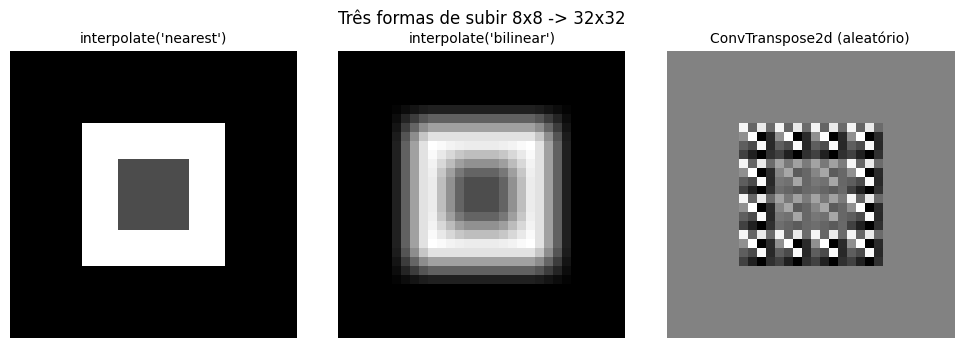


Dica: ConvTranspose2d com pesos não-treinados pode mostrar artefato de tabuleiro (checkerboard).


In [2]:
torch.manual_seed(0)

# 1) ConvTranspose2d aumentando 4x4 -> 8x8
ct = nn.ConvTranspose2d(1, 1, kernel_size=2, stride=2)
x = torch.randn(1, 1, 4, 4)
y = ct(x)
print("Entrada:", tuple(x.shape), "-> ConvTranspose2d:", tuple(y.shape))

# 2) Compara três upsamplings em uma imagem 8x8 sintética
img = torch.zeros(1, 1, 8, 8)
img[0, 0, 2:6, 2:6] = 1.0
img[0, 0, 3:5, 3:5] = 0.3

up_nn = F.interpolate(img, scale_factor=4, mode="nearest")
up_bi = F.interpolate(img, scale_factor=4, mode="bilinear", align_corners=False)
ct2 = nn.ConvTranspose2d(1, 1, kernel_size=4, stride=4)
up_ct = ct2(img).detach()

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, im, t in zip(
    axes,
    [up_nn[0, 0], up_bi[0, 0], up_ct[0, 0]],
    ["interpolate('nearest')", "interpolate('bilinear')", "ConvTranspose2d (aleatório)"]
):
    ax.imshow(im.numpy(), cmap="gray")
    ax.set_title(t, fontsize=10)
    ax.axis("off")
plt.suptitle("Três formas de subir 8x8 -> 32x32")
plt.tight_layout()
plt.show()

print("\nDica: ConvTranspose2d com pesos não-treinados pode mostrar artefato de tabuleiro (checkerboard).")

## 2. Dataset sintético de segmentação

Cada amostra é uma imagem `3x96x96` com 2-3 formas (quadrado, círculo, triângulo) sobre fundo cinza.
A **máscara** é um tensor `[H,W]` `long` onde cada pixel recebe o **rótulo da classe**:

| Rótulo | Classe    |
|--------|-----------|
| 0      | fundo     |
| 1      | quadrado  |
| 2      | círculo   |
| 3      | triângulo |

In [3]:
TAM = 96
NUM_CLASSES = 4  # 0=fundo, 1=quadrado, 2=círculo, 3=triângulo


def _desenhar_quadrado(img, mask, rng):
    lado = rng.integers(14, 28)
    x0 = rng.integers(0, TAM - lado)
    y0 = rng.integers(0, TAM - lado)
    cor = rng.uniform(0.3, 1.0, size=3).astype(np.float32)
    img[:, y0:y0 + lado, x0:x0 + lado] = cor[:, None, None]
    mask[y0:y0 + lado, x0:x0 + lado] = 1


def _desenhar_circulo(img, mask, rng):
    r = rng.integers(8, 16)
    cx = rng.integers(r, TAM - r)
    cy = rng.integers(r, TAM - r)
    yy, xx = np.ogrid[:TAM, :TAM]
    dentro = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    cor = rng.uniform(0.3, 1.0, size=3).astype(np.float32)
    for c in range(3):
        canal = img[c]
        canal[dentro] = cor[c]
    mask[dentro] = 2


def _desenhar_triangulo(img, mask, rng):
    lado = rng.integers(16, 30)
    x0 = rng.integers(0, TAM - lado)
    y0 = rng.integers(0, TAM - lado)
    cor = rng.uniform(0.3, 1.0, size=3).astype(np.float32)
    yy, xx = np.ogrid[:TAM, :TAM]
    # triângulo retângulo apontando para cima-esquerda
    dentro = (
        (xx >= x0) & (yy >= y0) & (xx <= x0 + lado) & (yy <= y0 + lado)
        & ((xx - x0) + (yy - y0) <= lado)
    )
    for c in range(3):
        canal = img[c]
        canal[dentro] = cor[c]
    mask[dentro] = 3


class DatasetSegmentacaoSintetica(Dataset):
    def __init__(self, n, seed=0):
        self.n = n
        self.seed = seed

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        rng = np.random.default_rng(self.seed + idx)
        img = np.full((3, TAM, TAM), 0.15, dtype=np.float32)
        mask = np.zeros((TAM, TAM), dtype=np.int64)
        n_formas = int(rng.integers(2, 4))
        desenhos = [_desenhar_quadrado, _desenhar_circulo, _desenhar_triangulo]
        for _ in range(n_formas):
            rng.choice(desenhos)(img, mask, rng)
        img += rng.normal(0, 0.02, size=img.shape).astype(np.float32)
        img = np.clip(img, 0.0, 1.0).astype(np.float32)
        return torch.from_numpy(img), torch.from_numpy(mask)


ds_treino = DatasetSegmentacaoSintetica(n=300, seed=0)
ds_teste = DatasetSegmentacaoSintetica(n=60, seed=10_000)
print(f"Treino: {len(ds_treino)} | Teste: {len(ds_teste)}")
img0, mask0 = ds_treino[0]
print(f"Imagem: {tuple(img0.shape)} {img0.dtype} | Máscara: {tuple(mask0.shape)} {mask0.dtype}")
print(f"Rótulos na máscara: {sorted(torch.unique(mask0).tolist())}")

Treino: 300 | Teste: 60
Imagem: (3, 96, 96) torch.float32 | Máscara: (96, 96) torch.int64
Rótulos na máscara: [0, 1, 2, 3]


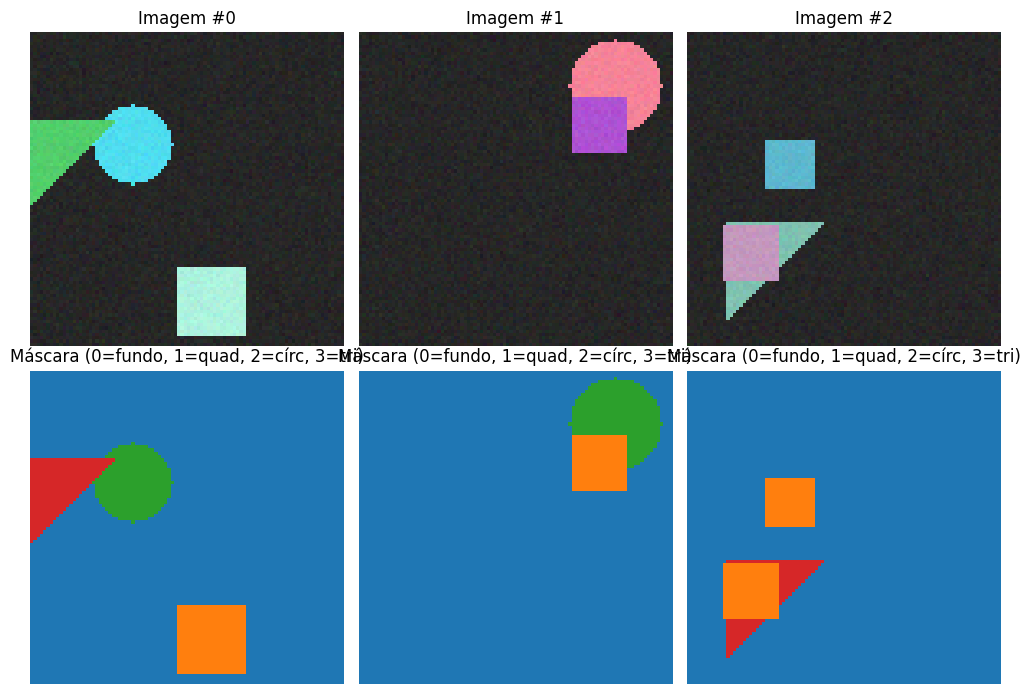

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for col in range(3):
    img, mask = ds_treino[col]
    axes[0, col].imshow(img.permute(1, 2, 0).numpy())
    axes[0, col].set_title(f"Imagem #{col}")
    axes[0, col].axis("off")
    axes[1, col].imshow(mask.numpy(), cmap="tab10", vmin=0, vmax=9)
    axes[1, col].set_title("Máscara (0=fundo, 1=quad, 2=círc, 3=tri)")
    axes[1, col].axis("off")
plt.tight_layout()
plt.show()

## 3. Mini U-Net

Estrutura clássica em **U**:
- **Encoder (descida):** blocos `Conv-BN-ReLU` + `MaxPool2d` reduzem espacialmente e aumentam canais.
- **Gargalo:** representação mais comprimida.
- **Decoder (subida):** `ConvTranspose2d` aumenta a resolução; concatenamos com o *skip connection* do encoder no mesmo nível e refinamos com mais convoluções.
- **Cabeça:** `Conv2d(., num_classes, kernel_size=1)` produz **um canal por classe**.

Resolução: `96 -> 48 -> 24 -> 12 -> 24 -> 48 -> 96`.

In [5]:
class DuplaConv(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.bloco = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.bloco(x)


class MiniUNet(nn.Module):
    def __init__(self, c_in=3, num_classes=NUM_CLASSES, base=16):
        super().__init__()
        self.enc1 = DuplaConv(c_in, base)            # 96 -> 96
        self.pool1 = nn.MaxPool2d(2)                 # 96 -> 48
        self.enc2 = DuplaConv(base, base * 2)        # 48
        self.pool2 = nn.MaxPool2d(2)                 # 48 -> 24
        self.enc3 = DuplaConv(base * 2, base * 4)    # 24
        self.pool3 = nn.MaxPool2d(2)                 # 24 -> 12
        self.gargalo = DuplaConv(base * 4, base * 8)  # 12
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)  # 12 -> 24
        self.dec3 = DuplaConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)  # 24 -> 48
        self.dec2 = DuplaConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)      # 48 -> 96
        self.dec1 = DuplaConv(base * 2, base)
        self.cabeca = nn.Conv2d(base, num_classes, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        s3 = self.enc3(self.pool2(s2))
        b = self.gargalo(self.pool3(s3))
        d3 = self.dec3(torch.cat([self.up3(b), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        return self.cabeca(d1)


modelo = MiniUNet().to(device)
n_params = sum(p.numel() for p in modelo.parameters())
print(f"MiniUNet | parâmetros: {n_params/1e6:.2f}M")
with torch.no_grad():
    saida_teste = modelo(torch.zeros(2, 3, TAM, TAM, device=device))
print(f"Forward (2,3,96,96) -> {tuple(saida_teste.shape)}")

MiniUNet | parâmetros: 0.48M


Forward (2,3,96,96) -> (2, 4, 96, 96)


## 4. Treino

Otimizador Adam, `CrossEntropyLoss` (que recebe logits `[B,C,H,W]` e máscara `long` `[B,H,W]`).
15 épocas devem ser suficientes — dataset sintético é fácil.

In [6]:
BATCH = 16
EPOCAS = 15

dl_treino = DataLoader(ds_treino, batch_size=BATCH, shuffle=True)
dl_teste = DataLoader(ds_teste, batch_size=BATCH, shuffle=False)

criterio = nn.CrossEntropyLoss()
otim = torch.optim.Adam(modelo.parameters(), lr=1e-3)

hist_loss = []
for epoca in range(1, EPOCAS + 1):
    modelo.train()
    soma = 0.0
    n = 0
    for x, y in dl_treino:
        x = x.to(device)
        y = y.to(device)
        logits = modelo(x)
        perda = criterio(logits, y)
        otim.zero_grad()
        perda.backward()
        otim.step()
        soma += perda.item() * x.size(0)
        n += x.size(0)
    media = soma / n
    hist_loss.append(media)
    if epoca == 1 or epoca % 3 == 0 or epoca == EPOCAS:
        print(f"Época {epoca:02d}/{EPOCAS} | loss treino: {media:.4f}")

print("Treino concluído.")

Época 01/15 | loss treino: 1.2861


Época 03/15 | loss treino: 0.8225


Época 06/15 | loss treino: 0.4794


Época 09/15 | loss treino: 0.2620


Época 12/15 | loss treino: 0.1371


Época 15/15 | loss treino: 0.0808
Treino concluído.


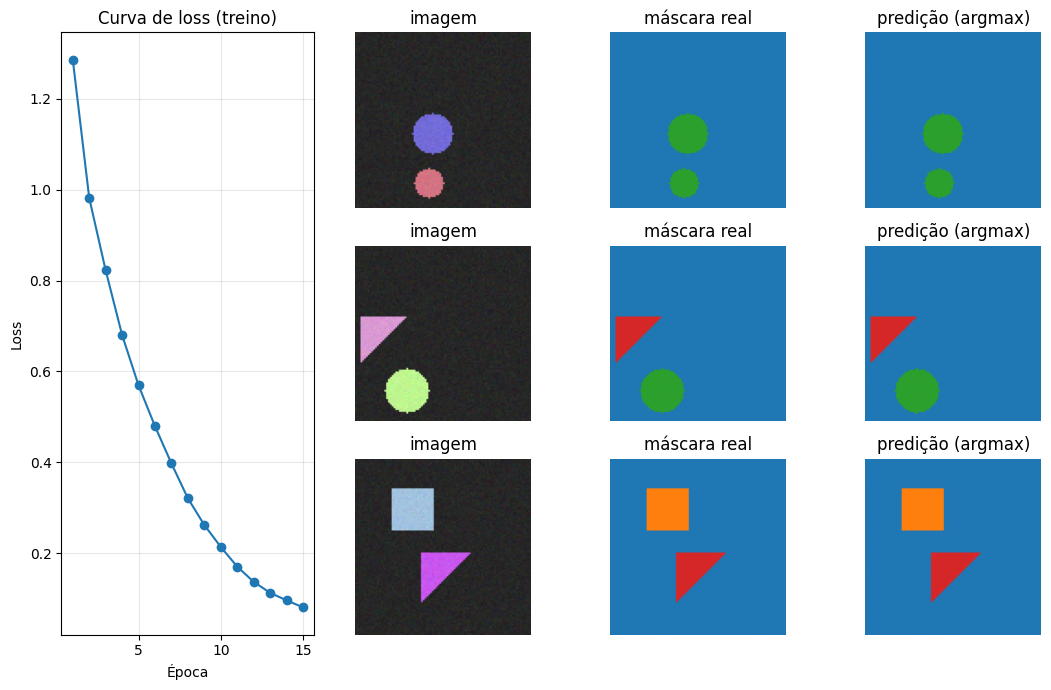

In [7]:
modelo.eval()

fig = plt.figure(figsize=(11, 7))
gs = fig.add_gridspec(3, 4)
ax_loss = fig.add_subplot(gs[:, 0])
ax_loss.plot(range(1, EPOCAS + 1), hist_loss, marker="o")
ax_loss.set_xlabel("Época"); ax_loss.set_ylabel("Loss")
ax_loss.set_title("Curva de loss (treino)")
ax_loss.grid(alpha=0.3)

with torch.no_grad():
    indices = [0, 7, 21]
    for linha, idx in enumerate(indices):
        img, mask = ds_teste[idx]
        logits = modelo(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).squeeze(0).cpu()
        ax_img = fig.add_subplot(gs[linha, 1])
        ax_img.imshow(img.permute(1, 2, 0).numpy()); ax_img.set_title("imagem"); ax_img.axis("off")
        ax_real = fig.add_subplot(gs[linha, 2])
        ax_real.imshow(mask.numpy(), cmap="tab10", vmin=0, vmax=9); ax_real.set_title("máscara real"); ax_real.axis("off")
        ax_pred = fig.add_subplot(gs[linha, 3])
        ax_pred.imshow(pred.numpy(), cmap="tab10", vmin=0, vmax=9); ax_pred.set_title("predição (argmax)"); ax_pred.axis("off")

plt.tight_layout()
plt.show()

## 5. Métricas de segmentação

- **Pixel Accuracy:** fração de pixels corretos. Pode ser enganosa quando há classes muito desbalanceadas (fundo domina).
- **IoU por classe** (Jaccard): `|A ∩ B| / |A ∪ B|`. Média das classes presentes = **mIoU**.
- **Dice por classe:** `2·|A ∩ B| / (|A| + |B|)`. Mais sensível a classes pequenas; equivalente ao F1 pixel a pixel.

In [8]:
def pixel_accuracy(pred, real):
    return (pred == real).float().mean().item()


def iou_por_classe(pred, real, num_classes):
    ious = []
    for c in range(num_classes):
        p = (pred == c)
        r = (real == c)
        inter = (p & r).sum().item()
        uniao = (p | r).sum().item()
        ious.append(float("nan") if uniao == 0 else inter / uniao)
    return ious


def dice_por_classe(pred, real, num_classes):
    dices = []
    for c in range(num_classes):
        p = (pred == c)
        r = (real == c)
        inter = (p & r).sum().item()
        soma = p.sum().item() + r.sum().item()
        dices.append(float("nan") if soma == 0 else (2 * inter) / soma)
    return dices


# Avaliação no teste (acumula tudo num único tensor)
modelo.eval()
preds_all, reais_all = [], []
with torch.no_grad():
    for x, y in dl_teste:
        x = x.to(device)
        logits = modelo(x)
        preds_all.append(logits.argmax(1).cpu())
        reais_all.append(y)
preds = torch.cat(preds_all)
reais = torch.cat(reais_all)

pa = pixel_accuracy(preds, reais)
ious = iou_por_classe(preds, reais, NUM_CLASSES)
dices = dice_por_classe(preds, reais, NUM_CLASSES)
miou = float(np.nanmean(ious))

nomes = ["fundo", "quadrado", "círculo", "triângulo"]
print(f"Pixel accuracy: {pa:.4f}")
print(f"\n{'classe':<10} {'IoU':>8} {'Dice':>8}")
print("-" * 30)
for nome, i, d in zip(nomes, ious, dices):
    print(f"{nome:<10} {i:>8.4f} {d:>8.4f}")
print("-" * 30)
print(f"mIoU (média das classes): {miou:.4f}")

Pixel accuracy: 0.9978

classe          IoU     Dice
------------------------------
fundo        1.0000   1.0000
quadrado     0.9404   0.9693
círculo      0.9540   0.9765
triângulo    0.9893   0.9946
------------------------------
mIoU (média das classes): 0.9709


## 6. Segmentação semântica pronta — DeepLabV3

`torchvision` traz **DeepLabV3** treinado no COCO (subset de classes do VOC, 21 categorias).
Mesma ideia da U-Net + *atrous convolutions* para campo receptivo maior sem perder resolução.

Imagem: (3, 256, 256) | min=0.00 max=1.00


Saída: (1, 21, 256, 256) | classes distintas no mapa: [0, 6, 15]


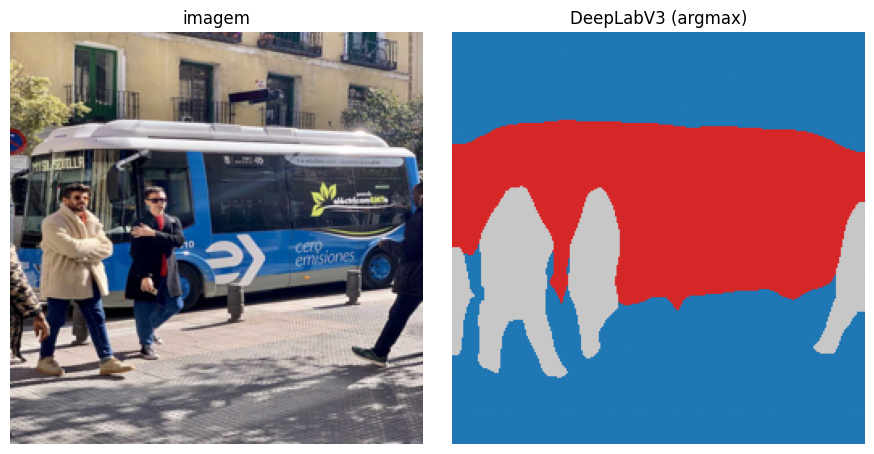

In [9]:
from urllib.request import urlretrieve


def carregar_imagem(tam=256):
    # 1) tenta um arquivo local
    for nome in ["exemplo.jpg", "exemplo.png"]:
        if os.path.exists(nome):
            from PIL import Image
            img = Image.open(nome).convert("RGB").resize((tam, tam))
            arr = np.asarray(img, dtype=np.float32) / 255.0
            return torch.from_numpy(arr).permute(2, 0, 1)
    # 2) tenta baixar uma foto pública
    try:
        url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
        dest = "_exemplo.jpg"
        urlretrieve(url, dest)
        from PIL import Image
        img = Image.open(dest).convert("RGB").resize((tam, tam))
        arr = np.asarray(img, dtype=np.float32) / 255.0
        return torch.from_numpy(arr).permute(2, 0, 1)
    except Exception:
        pass
    # 3) fallback sintético: 3 retângulos coloridos
    arr = np.full((tam, tam, 3), 0.4, dtype=np.float32)
    arr[40:140, 40:140] = [0.85, 0.2, 0.2]
    arr[80:200, 130:230] = [0.2, 0.75, 0.3]
    arr[150:240, 30:120] = [0.2, 0.3, 0.85]
    return torch.from_numpy(arr).permute(2, 0, 1)


imagem_exemplo = carregar_imagem(256)
print(f"Imagem: {tuple(imagem_exemplo.shape)} | min={imagem_exemplo.min():.2f} max={imagem_exemplo.max():.2f}")

try:
    from torchvision.models.segmentation import deeplabv3_resnet50
    rede = deeplabv3_resnet50(weights="DEFAULT").eval().to(device)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    entrada = ((imagem_exemplo - mean) / std).unsqueeze(0).to(device)
    with torch.no_grad():
        saida = rede(entrada)["out"]  # [1, 21, H, W]
    mapa_classes = saida.argmax(1).squeeze(0).cpu().numpy()
    print(f"Saída: {tuple(saida.shape)} | classes distintas no mapa: {np.unique(mapa_classes).tolist()}")

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(imagem_exemplo.permute(1, 2, 0).numpy()); axes[0].set_title("imagem"); axes[0].axis("off")
    axes[1].imshow(mapa_classes, cmap="tab20", vmin=0, vmax=20); axes[1].set_title("DeepLabV3 (argmax)"); axes[1].axis("off")
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"[aviso] DeepLabV3 não pôde rodar: {type(e).__name__}: {e}")
    print("Provável causa: pesos não estão no cache e sem internet. Pule esta célula em sala.")

## 7. Segmentação de instâncias — Mask R-CNN

Enquanto a semântica diz *"todo pixel deste pedaço é cachorro"*, a de **instâncias** distingue *"cachorro 1"* de *"cachorro 2"*.
**Mask R-CNN** estende o Faster R-CNN (notebook 3) com uma cabeça extra que prevê uma **máscara por instância detectada**.

Chaves da saída: ['boxes', 'labels', 'scores', 'masks']
masks shape: (38, 1, 256, 256) | scores: [1.0, 1.0, 1.0, 1.0, 0.7200000286102295, 0.6100000143051147]
Instâncias com score >= 0.5: 6


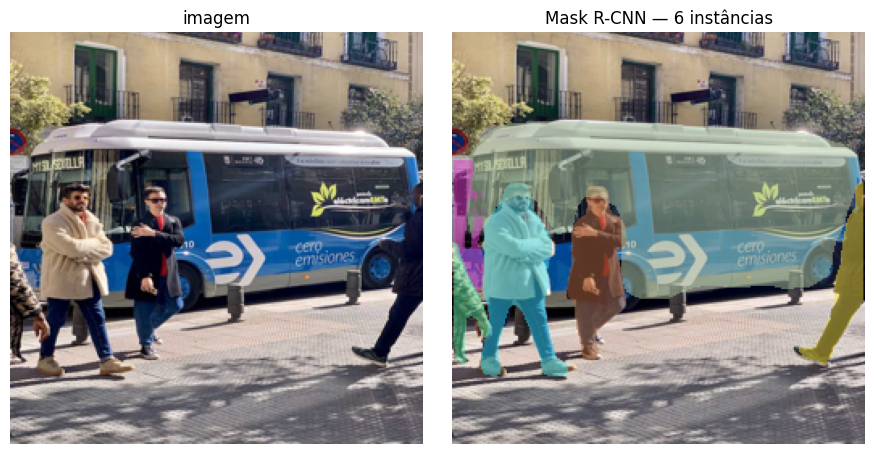

In [10]:
try:
    from torchvision.models.detection import maskrcnn_resnet50_fpn
    mrcnn = maskrcnn_resnet50_fpn(weights="DEFAULT").eval().to(device)
    with torch.no_grad():
        saida = mrcnn([imagem_exemplo.to(device)])[0]
    print("Chaves da saída:", list(saida.keys()))
    print(f"masks shape: {tuple(saida['masks'].shape)} | scores: {saida['scores'].cpu().numpy().round(2).tolist()[:6]}")

    bons = saida["scores"] >= 0.5
    mascaras = saida["masks"][bons].squeeze(1).cpu().numpy()  # [N, H, W]
    print(f"Instâncias com score >= 0.5: {mascaras.shape[0]}")

    # overlay: pinta cada instância com cor distinta
    rng = np.random.default_rng(0)
    overlay = imagem_exemplo.permute(1, 2, 0).numpy().copy()
    for m in mascaras:
        cor = rng.uniform(0.2, 1.0, size=3)
        binaria = m > 0.5
        overlay[binaria] = 0.5 * overlay[binaria] + 0.5 * cor

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(imagem_exemplo.permute(1, 2, 0).numpy()); axes[0].set_title("imagem"); axes[0].axis("off")
    axes[1].imshow(np.clip(overlay, 0, 1)); axes[1].set_title(f"Mask R-CNN — {mascaras.shape[0]} instâncias"); axes[1].axis("off")
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"[aviso] Mask R-CNN não pôde rodar: {type(e).__name__}: {e}")
    print("Mesmo motivo da célula anterior: pesos podem precisar de download.")

## 8. Exercício

Reproduza o pipeline da MiniUNet, mas troque a função de perda.

In [11]:
# TODO Exercicio 1: implemente a Dice loss (1 - Dice) e treine a MiniUNet com ela.
# Dica: aplique softmax sobre os logits ao longo do eixo de classes; one-hot na máscara
# real (use F.one_hot e permute); calcule Dice por classe e devolva 1 - média.
# Compare o mIoU final com o obtido pela CrossEntropy.
#
# Esqueleto:
# class DiceLoss(nn.Module):
#     def __init__(self, num_classes, eps=1e-6):
#         super().__init__()
#         self.num_classes = num_classes
#         self.eps = eps
#     def forward(self, logits, alvo):
#         # logits: [B,C,H,W]; alvo: [B,H,W] (long)
#         probs = F.softmax(logits, dim=1)
#         alvo_oh = F.one_hot(alvo, num_classes=self.num_classes).permute(0,3,1,2).float()
#         dims = (0,2,3)
#         inter = (probs * alvo_oh).sum(dim=dims)
#         soma = probs.sum(dim=dims) + alvo_oh.sum(dim=dims)
#         dice = (2*inter + self.eps) / (soma + self.eps)
#         return 1 - dice.mean()
pass

## 9. Resumo e encerramento da série

**Nesta aula você:**
- Praticou três formas de **upsampling** (`nearest`, `bilinear`, `ConvTranspose2d`).
- Implementou uma **MiniUNet** do zero (encoder, gargalo, decoder com *skip connections*).
- Treinou um modelo de **segmentação semântica** em dataset sintético.
- Avaliou com **Pixel Accuracy, IoU e Dice por classe** e calculou o **mIoU**.
- Conheceu modelos prontos do torchvision: **DeepLabV3** (semântica) e **Mask R-CNN** (instâncias).

**Recapitulando a série (4 notebooks):**
1. CNNs do zero e blocos fundamentais.
2. Classificação com transfer learning.
3. Detecção (sliding window, Faster R-CNN, YOLO).
4. Segmentação semântica e de instâncias.

**Próximo passo (fora do escopo desta aula):**
> Modelos *foundation* como o **SAM (Segment Anything Model)** da Meta — segmentação "de qualquer coisa" via prompts (pontos, caixas, texto). É a fronteira atual entre segmentação clássica e visão **promptável**, e um ótimo tema para um projeto.

**Boa caminhada!**